<a href="https://colab.research.google.com/github/anastasiatam/Engineering-with-Machine-Learning/blob/main/homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question 1**

In [2]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

iris = datasets.load_iris()

In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

target = function of feature names

---


(setosa, versicolor, viriginica) = f(sepal length, sepal width, petal length, petal width)

In [6]:
X = iris.data
y = iris.target

In [7]:
X.shape

(150, 4)

In [8]:
y.shape

(150,)

Text(0, 0.5, 'sepal width (cm)')

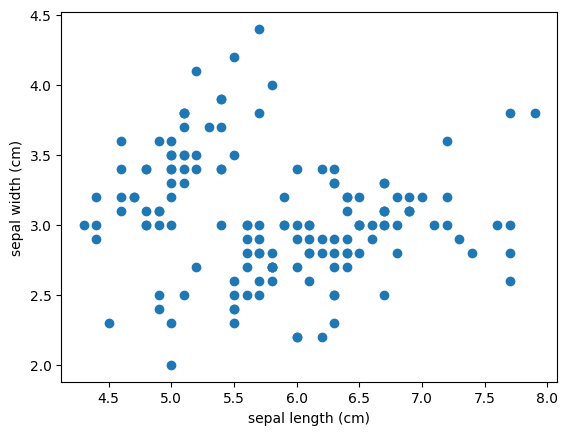

In [9]:
plt.scatter(X[:,0],X[:,1])
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

Text(0, 0.5, 'sepal width (cm)')

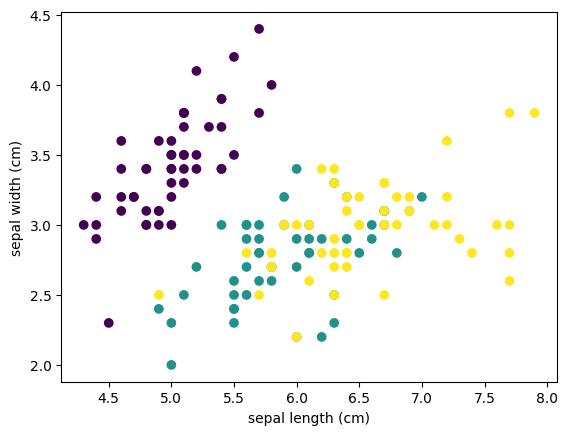

In [10]:
plot = plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
# plt.legend(handles=plot.legend_elements()[0], labels=iris.target_names.tolist())

Define two new features

In [11]:
sepal_area = iris.data[:, 0] * iris.data[:, 1]  # sepal length * sepal width
petal_area = iris.data[:, 2] * iris.data[:, 3]  # petal length * petal width

In [12]:
#X = iris.data[:, :2] # only selecting first two features
#y = iris.target
X = np.column_stack((sepal_area, petal_area))
y = iris.target

we are going to split the data and keep some of the data seperate for testing the model

In [13]:
X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.40,
    train_size=0.60,
    random_state=123,
    shuffle=True,
    stratify=y)


import support vector machine model and train it

In [14]:
clf = svm.SVC()
clf.fit(X_train, y_train)

SVC()

In [15]:
preds = clf.predict(X_test)
print(preds)

[1 1 1 1 0 2 1 0 0 2 0 2 2 2 2 0 1 2 0 2 2 0 1 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 1 0 0 1 1 2 1 2 1 1 2 1 2]


In [16]:
print('actual iris species')
print(y_test)

actual iris species
[1 1 1 1 0 1 2 0 0 2 0 2 2 1 2 0 1 2 0 2 2 0 1 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 1 0 0 1 1 2 1 2 1 1 2 1 2]


In [17]:
acc = accuracy_score(y_test,clf.predict(X_test) )
print('accuracy score :', acc)

accuracy score : 0.95


# **Question 2**

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [19]:
# Load MNIST Dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Filter dataset for EVEN digits ONLY (0, 2, 4, 6, 8)
even_mask = (y % 2 == 0)
X_even = X[even_mask]
y_even = y[even_mask]

# Note: Keeping X_even shape as (N, 784) ensures every pixel is considered!

In [20]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_even, y_even,
    test_size=0.30,
    random_state=42,
    stratify=y_even
)

# Subsample 5,000 training rows for GridSearchCV
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train,
    train_size=5000,
    random_state=42,
    stratify=y_train
)

In [21]:
# Define Parameter Grid for Hyperparameter Tuning
# Note: Reduced cv=3 and p=[1, 2] so grid search runs quickly on pixel data
param_grid = {
    "n_neighbors": range(1, 10),
    "p": [1, 2]  # 1 = Manhattan distance, 2 = Euclidean distance
}

In [22]:
# Initialize and Run GridSearchCV on the smaller subset
print("Searching for best k-NN hyperparameters...")
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sub, y_train_sub)

# Display best parameter combination found
print("\nBest Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Searching for best k-NN hyperparameters...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Hyperparameters: {'n_neighbors': 3, 'p': 2}
Best Cross-Validation Accuracy: 0.9772


In [23]:
# Evaluate Best Model on the Test Set
best_knn = grid_search.best_estimator_

best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Final Test Set Accuracy: {test_acc:.4f}\n")

Final Test Set Accuracy: 0.9887



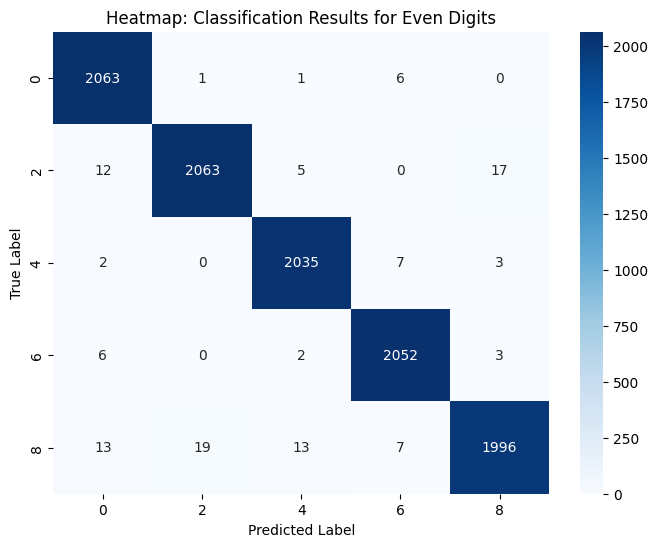

In [24]:
# Heatmap Visualization of Correct vs. Incorrect Classifications
even_labels = [0, 2, 4, 6, 8]
cm = confusion_matrix(y_test, y_pred, labels=even_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=even_labels,
            yticklabels=even_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Heatmap: Classification Results for Even Digits')
plt.show()

In [25]:
# Calculate Correctly Classified '6's
six_idx = even_labels.index(6)  # Index of digit 6 in [0, 2, 4, 6, 8]
correct_6s = cm[six_idx, six_idx]
total_6s = np.sum(y_test == 6)

print(f"\nTotal '6's in test set: {total_6s}")
print(f"Correctly classified '6's: {correct_6s}")
print(f"Accuracy on digit '6': {(correct_6s / total_6s) * 100:.2f}%")


Total '6's in test set: 2063
Correctly classified '6's: 2052
Accuracy on digit '6': 99.47%


# **Question 3**

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import silhouette_score
from scipy.optimize import linear_sum_assignment
import ipywidgets as widgets
from ipywidgets import interact

In [38]:
# Custom KMeans Algorithm

class KMeans:
    def __init__(self, k, max_iters=300, n_init=10):
        self.k = k
        self.max_iters = max_iters
        self.n_init = n_init
        self.cluster_labels = np.arange(self.k)
        self.centroids = None
        self.clusters = None
        self.inertia_ = None

    def _fit_single(self, X):
        """Runs one single trial of K-Means clustering."""
        # Randomly choose initial centroids
        centroids = X[np.random.choice(X.shape[0], self.k, replace=False), :]

        for _ in range(self.max_iters):
            distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in centroids])
            clusters = np.argmin(distances, axis=0)

            # Recalculate centroids
            new_centroids = np.array([
                X[clusters == i, :].mean(axis=0) if np.sum(clusters == i) > 0
                else centroids[i]
                for i in range(self.k)
            ])

            if np.allclose(new_centroids, centroids):
                break

            centroids = new_centroids

        # Calculate inertia for this single trial
        min_distances = np.min(np.array([np.linalg.norm(X - c, axis=1)**2 for c in centroids]), axis=0)
        inertia = np.sum(min_distances)

        return centroids, clusters, inertia

    def fit(self, X):
        """Runs n_init trials and keeps the run with the lowest inertia."""
        best_inertia = float('inf')

        for _ in range(self.n_init):
            centroids, clusters, inertia = self._fit_single(X)
            if inertia < best_inertia:
                best_inertia = inertia
                self.centroids = centroids
                self.clusters = clusters
                self.inertia_ = inertia

        return self

    def predict(self, X):
        distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
        return self.cluster_labels[np.argmin(distances, axis=0)]

In [45]:
# Helper function: Aligns custom cluster colors to match sklearn's output
def align_labels(ref_labels, pred_labels):
    D = max(pred_labels.max(), ref_labels.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=int)
    for r, p in zip(ref_labels, pred_labels):
        cost_matrix[p, r] += 1
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)
    mapping = dict(zip(row_ind, col_ind))
    return np.array([mapping[l] for l in pred_labels]), mapping

In [46]:
# Data Preparation

np.random.seed(42)

iris = load_iris()
X = iris.data[:, :3]  # Select THREE features (Sepal Length, Sepal Width, Petal Length)
feature_names = iris.feature_names[:3]

# Fit Custom KMeans
custom_model = KMeans(k=3)
custom_model.fit(X)
custom_labels = custom_model.predict(X)

# Fit Sklearn KMeans
sklearn_model = SklearnKMeans(n_clusters=3, random_state=42, n_init=10).fit(X)
sklearn_labels = sklearn_model.labels_

# Align colors so both plots match visually
aligned_custom_labels, mapping = align_labels(sklearn_labels, custom_labels)
aligned_centroids = np.zeros_like(custom_model.centroids)
for custom_idx, sklearn_idx in mapping.items():
    aligned_centroids[sklearn_idx] = custom_model.centroids[custom_idx]

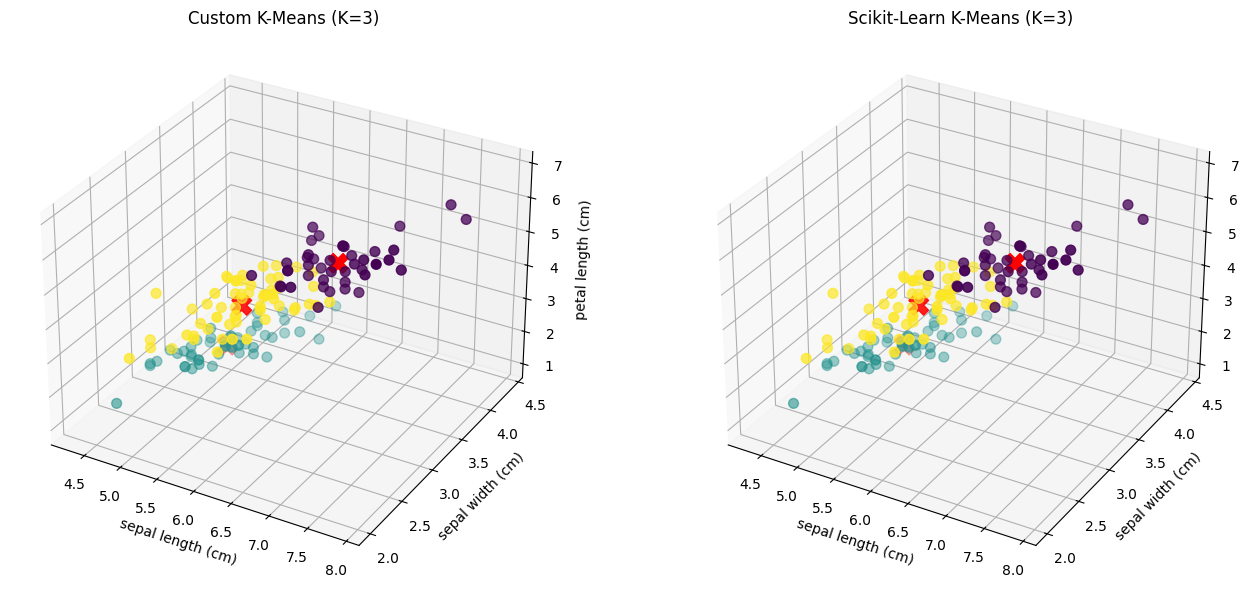

In [47]:
# 3D Scatter Plot Comparison

fig = plt.figure(figsize=(14, 6))

# Custom Subplot
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=aligned_custom_labels, cmap='viridis', s=50)
ax1.scatter(aligned_centroids[:, 0], aligned_centroids[:, 1], aligned_centroids[:, 2],
            c='red', marker='X', s=200, label='Centroids')
ax1.set_title(f'Custom K-Means (K=3)')
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.set_zlabel(feature_names[2])

# Sklearn Subplot
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=sklearn_labels, cmap='viridis', s=50)
ax2.scatter(sklearn_model.cluster_centers_[:, 0], sklearn_model.cluster_centers_[:, 1], sklearn_model.cluster_centers_[:, 2],
            c='red', marker='X', s=200, label='Centroids')
ax2.set_title(f'Scikit-Learn K-Means (K=3)')
ax2.set_xlabel(feature_names[0])
ax2.set_ylabel(feature_names[1])
ax2.set_zlabel(feature_names[2])

plt.tight_layout()
plt.show()

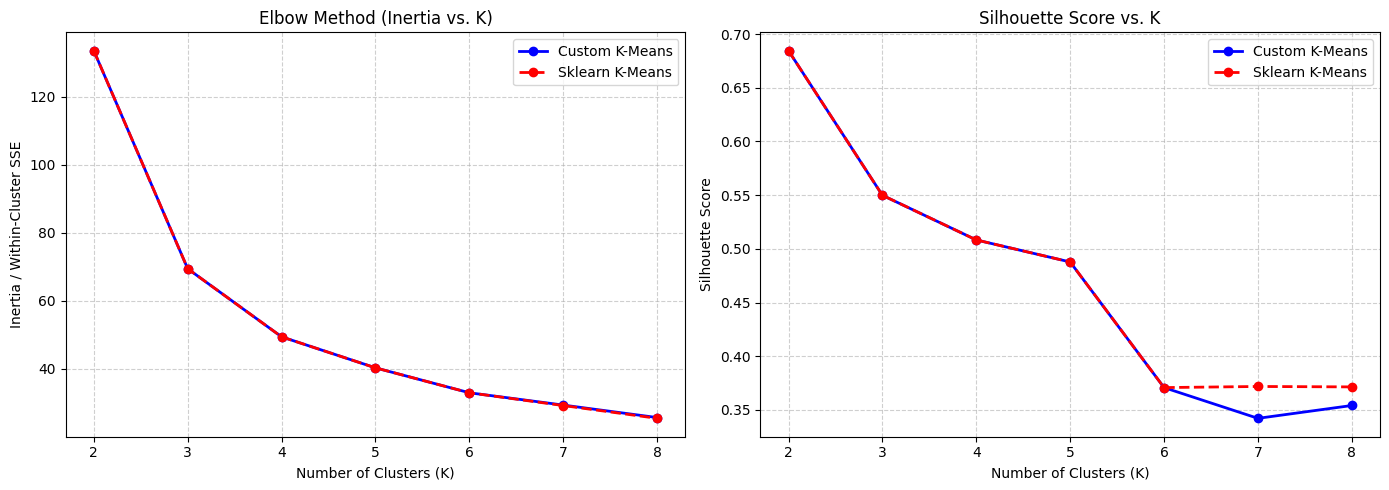

In [48]:
# Static Diagnostic Plots (Elbow & Silhouette)
k_range = range(2, 9)
custom_inertias, sklearn_inertias = [], []
custom_silhouettes, sklearn_silhouettes = [], []

for k in k_range:
    # Custom Model
    c_model = KMeans(k=k, n_init=10)
    c_model.fit(X)
    c_labs = c_model.predict(X)
    custom_inertias.append(c_model.inertia_)
    custom_silhouettes.append(silhouette_score(X, c_labs))

    # Sklearn Model
    sk_model = SklearnKMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sklearn_inertias.append(sk_model.inertia_)
    sklearn_silhouettes.append(silhouette_score(X, sk_model.labels_))

# Plot Diagnostic Curves
fig2, (ax1_metric, ax2_metric) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Method (Inertia vs K)
ax1_metric.plot(k_range, custom_inertias, 'bo-', label='Custom K-Means', linewidth=2)
ax1_metric.plot(k_range, sklearn_inertias, 'ro--', label='Sklearn K-Means', linewidth=2)
ax1_metric.set_title('Elbow Method (Inertia vs. K)')
ax1_metric.set_xlabel('Number of Clusters (K)')
ax1_metric.set_ylabel('Inertia / Within-Cluster SSE')
ax1_metric.set_xticks(k_range)
ax1_metric.grid(True, linestyle='--', alpha=0.6)
ax1_metric.legend()

# Plot 2: Silhouette Score vs K
ax2_metric.plot(k_range, custom_silhouettes, 'bo-', label='Custom K-Means', linewidth=2)
ax2_metric.plot(k_range, sklearn_silhouettes, 'ro--', label='Sklearn K-Means', linewidth=2)
ax2_metric.set_title('Silhouette Score vs. K')
ax2_metric.set_xlabel('Number of Clusters (K)')
ax2_metric.set_ylabel('Silhouette Score')
ax2_metric.set_xticks(k_range)
ax2_metric.grid(True, linestyle='--', alpha=0.6)
ax2_metric.legend()

plt.tight_layout()
plt.show()